In [1]:
import torch
import torch.nn as nn
from torchvision import transforms, datasets
import torch.nn.functional as F
import math

In [2]:
class Encoder(nn.Module):
    def __init__(self, embed_size=768, num_heads=3, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(embed_size)
        self.attention = nn.MultiheadAttention(embed_size, num_heads, dropout, batch_first=True)
        self.ln2 = nn.LayerNorm(embed_size)
        self.ff = nn.Sequential(
            nn.Linear(embed_size, 4 * embed_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * embed_size, embed_size),
            nn.Dropout(dropout)
        )
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        x = self.ln1(x)
        x = x + self.attention(x, x, x)[0]
        x = x + self.ff(self.ln2(x))
        return x

In [3]:
a = torch.randn((1,3,16,16))
b = a.unfold(2,8,8).unfold(3,8,8)
b.contiguous().shape

torch.Size([1, 3, 2, 2, 8, 8])

In [ ]:
class VisionTransformer(nn.Module):
    def __init__(self, in_channels=3, num_encoders=6, embed_size=768, img_size=(324, 324), patch_size=16, num_classes=10, num_heads=4):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        num_tokens = (img_size[0]*img_size[1])//(patch_size**2)
        self.class_token = nn.Parameter(torch.randn((embed_size,)), requires_grad=True)
        self.patch_embedding = nn.Linear(in_channels*patch_size**2,embed_size)
        self.pos_embedding = nn.Parameter(torch.randn((num_tokens+1, embed_size)), requires_grad=True)
        self.encoders = nn.ModuleList([
            Encoder(embed_size=embed_size, num_heads=num_heads) for _ in range(num_encoders)
        ])
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_size),
            nn.Linear(embed_size, num_classes)
        )
    def forward(self, x):
        batch_size, channel_size = x.shape[:2]
        patches = x.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        patches = patches.contiguous().view(x.size(0), -1, channel_size*self.patch_size*self.patch_size)
        x = self.patch_embedding(patches)
        class_token = self.class_token.unsqueeze(0).repeat(batch_size, 1, 1)
        x = torch.cat([class_token, x], dim=1)  
        x = x + self.pos_embedding.unsqueeze(0)
        for encoder in self.encoders:
            x = encoder(x)
        x = x[:,0, :].squeeze()
        x = self.mlp_head(x)
        return x

In [5]:
from torchinfo import summary

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = VisionTransformer(in_channels=1, img_size=(28,28), patch_size=4, embed_size=64, num_heads=4, num_encoders=2).to(device)
summary(model, [2,1,28,28])

torch.Size([2, 49, 16])


Layer (type:depth-idx)                   Output Shape              Param #
VisionTransformer                        [2, 10]                   3,264
├─Linear: 1-1                            [2, 49, 64]               1,088
├─ModuleList: 1-2                        --                        --
│    └─Encoder: 2-1                      [2, 50, 64]               --
│    │    └─LayerNorm: 3-1               [2, 50, 64]               128
│    │    └─MultiheadAttention: 3-2      [2, 50, 64]               16,640
│    │    └─LayerNorm: 3-3               [2, 50, 64]               128
│    │    └─Sequential: 3-4              [2, 50, 64]               33,088
│    └─Encoder: 2-2                      [2, 50, 64]               --
│    │    └─LayerNorm: 3-5               [2, 50, 64]               128
│    │    └─MultiheadAttention: 3-6      [2, 50, 64]               16,640
│    │    └─LayerNorm: 3-7               [2, 50, 64]               128
│    │    └─Sequential: 3-8              [2, 50, 64]           

In [46]:
data_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.1307], std=[0.3081])
])

train_data = datasets.MNIST(root = './data/',
                            train=True,
                            download=True,
                            transform=data_transforms)
test_data = datasets.MNIST(root = './data/',
                            train=False,
                            download=True,
                            transform=data_transforms)

In [47]:
from tqdm import tqdm
train_dl = torch.utils.data.DataLoader(train_data, batch_size=128, shuffle=True)
test_dl = torch.utils.data.DataLoader(test_data, batch_size=1024, shuffle=False)
optimizer = torch.optim.Adam(lr=1e-2, params=model.parameters())
criterion = nn.CrossEntropyLoss()

In [48]:
epochs = 10
for epoch in range(epochs):
    losses = []
    print(f"Epoch {epoch+1} / {epochs}", end=" ")
    for image, label in tqdm(train_dl):
        image, label = image.to(device), label.to(device)
        pred = model(image)
        loss = criterion(pred, label)
        loss.backward()
        losses.append(loss.item())
        optimizer.step()
        optimizer.zero_grad()
    print(f"loss: {sum(losses) / len(losses)}", end=" ")
    with torch.no_grad():
        cnt, correct_cnt = 0, 0
        for image, label in test_dl:
            image, label = image.to(device), label.to(device)
            pred = model(image).argmax(dim=1)
            cnt += label.shape[0]
            correct_cnt += (pred==label).sum().item()
        print("accuracy: ", correct_cnt / cnt)
torch.save(model.state_dict(), './model.pt')


Epoch 1 / 10 

100%|██████████| 469/469 [00:03<00:00, 122.87it/s]


loss: 0.563767385381117 accuracy:  0.8955
Epoch 2 / 10 

100%|██████████| 469/469 [00:03<00:00, 124.52it/s]


loss: 0.29759083648543877 accuracy:  0.9257
Epoch 3 / 10 

...

loss: 0.16926545164446588 accuracy:  0.9534
Epoch 9 / 10 

100%|██████████| 469/469 [00:03<00:00, 124.82it/s]


loss: 0.153582838568479 accuracy:  0.9563
Epoch 10 / 10 

100%|██████████| 469/469 [00:03<00:00, 123.46it/s]


loss: 0.1399369302199784 accuracy:  0.9521


In [43]:
a = next(iter(train_dl))[0][0]
a.cpu().numpy().transpose(1,2,0).shape

(28, 28, 1)

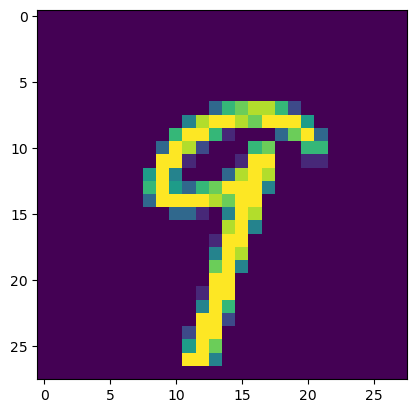

In [44]:
import matplotlib.pyplot as plt
test_img = next(iter(train_dl))[0][0]
plt.imshow(test_img.cpu().numpy().transpose(1,2,0))

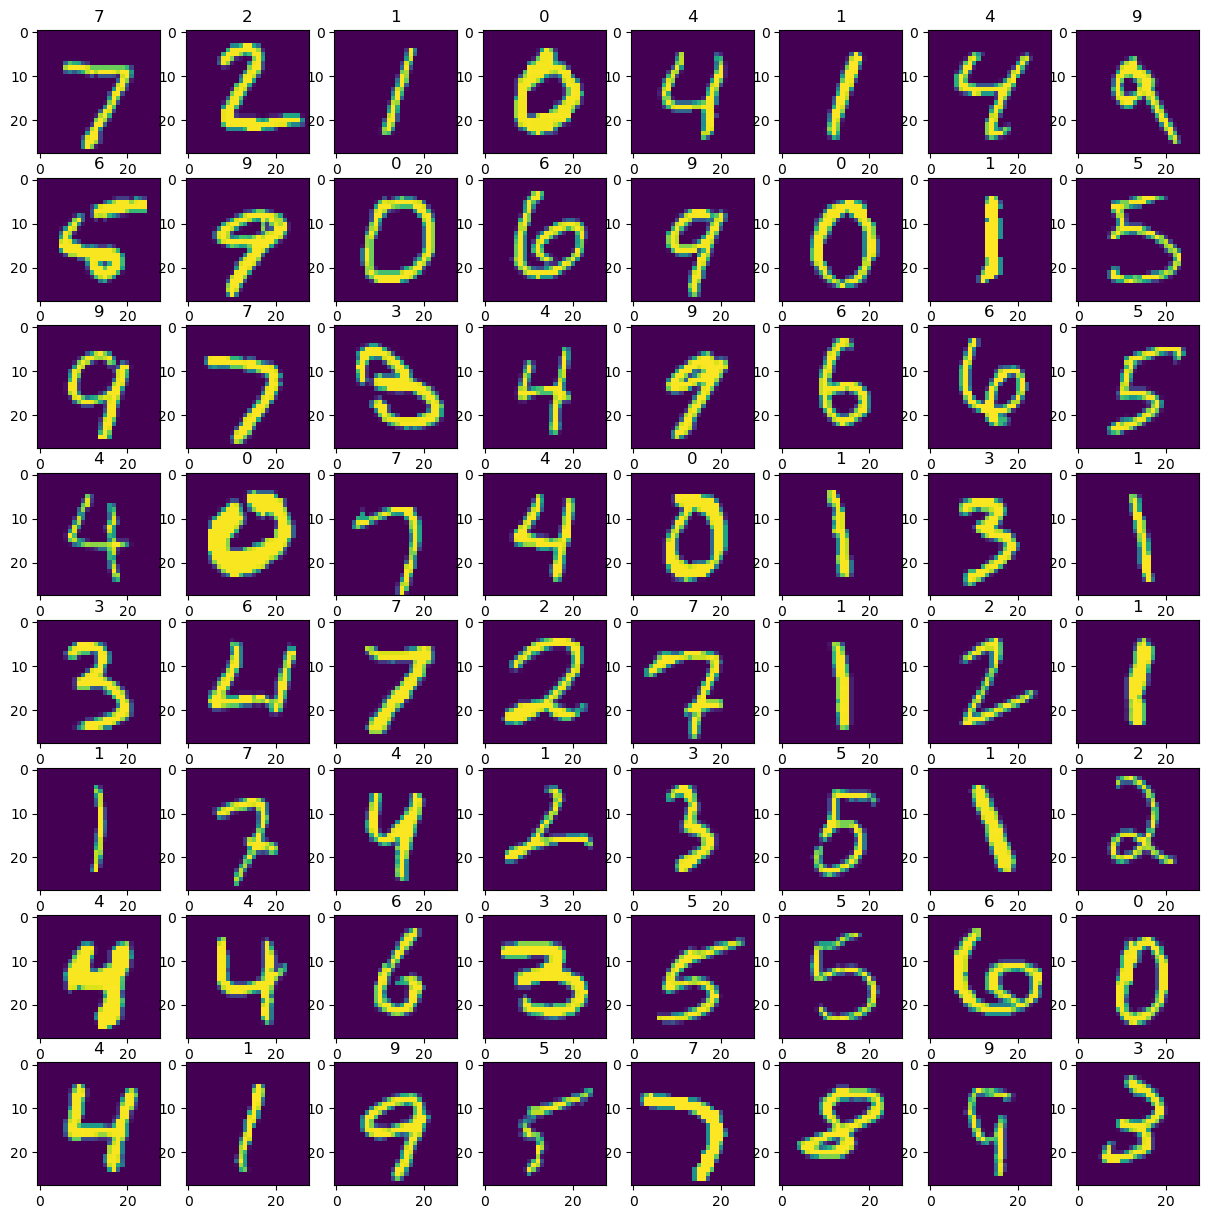

In [49]:
import matplotlib.pyplot as plt
with torch.no_grad():
    for image, _ in test_dl:
        image = image[:64]
        image = image.to(device)
        pred = model(image).argmax(dim=1).cpu().detach().numpy()
        image = image.cpu().detach().numpy()
        break
    fig, axes = plt.subplots(8, 8, figsize=(15, 15))
    for i in range(64):
        axes[i//8][i%8].set_title(pred[i])
        axes[i//8][i%8].imshow(image[i][0])
